### **Package**

In [1]:
import subprocess
import sys
import os

print(sys.version)

try:
    import pymoo
    print("pymoo is already installed.")
except ImportError:
    print("pymoo is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymoo"])
print("pymoo installed.")

try:
    import GPy
    print("GPy is already installed.")
except ImportError:
    print("GPy is not installed. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "GPy"])
print("GPy installed.")


import warnings
warnings.filterwarnings("ignore", message=".*load_learner.*pickle.*")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pymoo is already installed.
pymoo installed.
GPy is already installed.
GPy installed.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/PhD 2026-1 New metric ')

from src.opt_problem import build_problem, Benchmark_Problem, EvaluatePreRealCallback, evaluate_pre_real
from src.survival import Survival_standard, Survival_dual_ranking
from src.data import generate_data
from src.metrics import get_metrics
from src.models import GPR_RBF, gpr_pred_mean_std
from src.uncertainty import coverage, find_alpha
from src.experiment import run_experiment
from src.other_functions import mean_std, print_gpr_params
from src.plotting import plot_z_score, plot_obj_2d

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Main**

###### 1. Initial settings

In [3]:
# Problem: dtlz1-7, omnitest, bnh, truss2d, welded_beam
problem_name = 'dtlz1'
n_var = 10
n_obj = 2
problem = build_problem(
    problem_name = problem_name,
    n_var = n_var,
    n_obj = n_obj)
print(f"Problem name: {problem_name}")
print(f"Cons: {problem.n_constr}")
print(f"Var: {n_var}")
print(f"Obj: {n_obj}")

# EC algorithm: n_gen, pop_size
n_gen = 100
pop_size = 100

# Data: LHS sampling with seed 42
random_seed = 42
sampling = LHS()
sample_size = 11*n_var-1
X_train, y_train, X_val, y_val, X_test, y_test = generate_data(
    problem=problem,
    sample_size=sample_size,
    sampling = sampling,
    train_seed=random_seed,
    val_size=100,
    test_size=100,
    test_seed=1)
y_train_f1 = y_train[:, 0]
y_train_f2 = y_train[:, 1]
print(f"\nSampling X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

# Metrics
hv, igd_plus, obj_min, obj_max, ref_point = get_metrics(
    problem_name = problem_name,
    problem = problem,
    n_var=n_var,
    n_obj=n_obj)
print('\nMin-Max normalization -> Min: ', obj_min)
print('Min-Max normalization -> Max: ', obj_max)
print('HV Reference points: ', ref_point)

np.set_printoptions(precision=4, suppress=True)

Problem name: dtlz1
Cons: 0
Var: 10
Obj: 2

Sampling X_train shape: (109, 10)
y_train shape: (109, 2)
y_val shape: (100, 2)
y_test shape: (100, 2)

Min-Max normalization -> Min:  [0 0]
Min-Max normalization -> Max:  [700 700]
HV Reference points:  [1.1 1.1]


###### 2. Surrogate model training

In [4]:
model_f1 = GPR_RBF()
model_f2 = GPR_RBF()

model_f1.fit(X_train, y_train_f1)
model_f2.fit(X_train, y_train_f2)
print_gpr_params(model_f1, model_f2)

# Predict
pred_mean, pred_std, mean_f1, std_f1, mean_f2, std_f2 = gpr_pred_mean_std(
    model_f1,
    model_f2,
    X_test,
    noiseless=False)
print(f"\nGPR(RBF) MSE: {mean_squared_error(y_test, pred_mean):.2e}\n")

f1 lengthscale: [  1.8323  20.5002 487.9242  33.738   27.1506 770.0908 138.0009 271.7149
 610.1232 530.1334]
f1 kernel variance: [12.811]
f1 noise: [0.1875]
f2 lengthscale: [    1.0359 19125.9641     3.4437 23025.8925 15948.8549 19731.5852
    12.3385 26808.5642 28713.6129    14.8014]
f2 kernel variance: [4.4718]
f2 noise: [0.1124]
[with_noise] pred_mean
 [[322.1184 156.5512]
 [147.6595 341.9892]
 [ 83.1005 434.2483]
 [ 20.5039 514.1561]
 [103.2507 390.0511]]
[with_noise] pred_std
 [[65.6409 54.6089]
 [65.5437 54.5509]
 [65.8873 55.4862]
 [66.7778 55.6344]
 [65.7424 54.4159]]
[with_noise] Max pred_std
 [67.359  57.6211]

GPR(RBF) MSE: 4.67e+03



###### 2.1 CICP & Z score

k=1.645: per_dim=[93. 84.]%, overall=88.5%


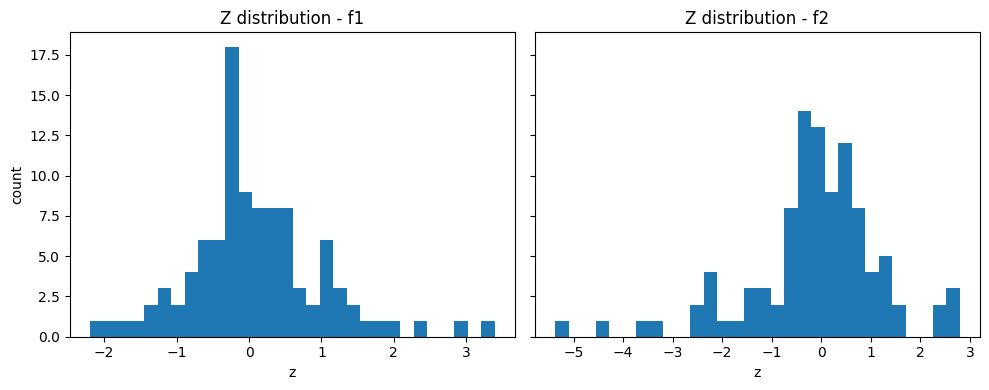

In [5]:
###### CICP
"""
Interval    Coverage
±1.282σ      80.00%
±1.645σ      90.00%
±1.960σ      95.00%
"""

for k in [1.645]:
    per_dim, overall = coverage(y_test, pred_mean, pred_std, k=k)
    print(f"k={k}: per_dim={per_dim*100}%, overall={overall*100:.1f}%")

###### Z score
plot_z_score(y_test, pred_mean, pred_std)

###### 2.2 find_alpha

In [6]:
alpha_c90_f1 = find_alpha(
    X_val, y_val[:,0],
    model_f1,
    target_coverage=0.9)
alpha_c90_f2 = find_alpha(
    X_val, y_val[:,1],
    model_f2,
    target_coverage=0.9)
print(f"alpha_c90_f1={alpha_c90_f1:.2f}, alpha_c90_f2={alpha_c90_f2:.2f}")

F_upper_c90 = np.stack(
    [mean_f1 + alpha_c90_f1 * std_f1,
     mean_f2 + alpha_c90_f2 * std_f2], axis=1)
print('F_upper_c90\n', F_upper_c90[0:5],'\n')

coverage=90.00%
coverage=90.00%
alpha_c90_f1=1.23, alpha_c90_f2=1.05
F_upper_c90
 [[402.8568 213.8905]
 [228.2782 399.2677]
 [164.1419 492.5088]
 [102.6406 572.5722]
 [184.1139 447.1878]] 



###### 3. Optimization

In [11]:
results = run_experiment(
    problem=problem,
    problem_name=problem_name,
    n_gen=n_gen,
    pop_size=pop_size,
    model_f1=model_f1,
    model_f2=model_f2,
    obj_min=obj_min,
    obj_max=obj_max,
    hv=hv,
    igd_plus=igd_plus,
    use_surrogate="GPR_uncertainty", ### change
    survival_function=Survival_standard(), ### change
    use_callback=False, ### change
    seeds=range(1, 3)) ### change

mse_list = results["mse_list"]
igd_list = results["igd_list"]
hv_surrogate_list = results["hv_surrogate_list"]
hv_real_list = results["hv_real_list"]

obj = results["run_details"][-1]["obj"]
f_real = results["run_details"][-1]["f_real"]
solution = results["run_details"][-1]["solution"]

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))


Seed 1 | Time: 10.72s | MSE: 7.62e+03 | igd+: 1.37e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [444.8717 515.8631] | Max f_real: [387.5999 393.4155]
Seed 2 | Time: 8.01s | MSE: 9.90e+03 | igd+: 1.01e+02 | Sur HV: 1.03 | Real HV: 1.17 | Max obj: [444.8962 514.6106] | Max f_real: [374.0489 390.3563]


In [ ]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== GPR ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")

###### 3. Optimization GPR (RBF) + dual-ranking (c=0.90)

In [10]:
results = run_experiment(
    problem=problem,
    problem_name=problem_name,
    n_gen=n_gen,
    pop_size=pop_size,
    model_f1=model_f1,
    model_f2=model_f2,
    obj_min=obj_min,
    obj_max=obj_max,
    hv=hv,
    igd_plus=igd_plus,
    use_surrogate="GPR_uncertainty", ### change
    survival_function=Survival_dual_ranking(
        alpha_f1=alpha_c90_f1,
        alpha_f2=alpha_c90_f2), ### change
    use_callback=False, ### change
    seeds=range(1, 2)) ### change

mse_list = results["mse_list"]
igd_list = results["igd_list"]
hv_surrogate_list = results["hv_surrogate_list"]
hv_real_list = results["hv_real_list"]

obj = results["run_details"][-1]["obj"]
f_real = results["run_details"][-1]["f_real"]
solution = results["run_details"][-1]["solution"]

plot_obj_2d(obj,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))
plot_obj_2d(f_real,
            xlim=(float(obj_min[0])-0.3*float(obj_max[0]), float(obj_max[0])),
            ylim=(float(obj_min[1])-0.3*float(obj_max[1]), float(obj_max[1])))


Seed 1 | Time: 10.82s | MSE: 8.78e+03 | igd+: 1.26e+02 | Sur HV: 1.03 | Real HV: 1.16 | Max obj: [444.77   514.0389] | Max f_real: [386.5693 393.9242]


In [ ]:
# mean_mse, std_mse = mean_std(mse_list)
# mean_igd, std_igd = mean_std(igd_list)
# mean_hv_real, std_hv_real = mean_std(hv_real_list)
# mean_hv_surrogate, std_hv_surrogate = mean_std(hv_surrogate_list)

# print('Problem name: ', problem_name)
# print("\n=== GPR + dual-ranking + alpha_c90  ===")

# print(f"MSE: Mean = {mean_mse:.2e}, Std = {std_mse:.2e}")
# print(f"IGD+: Mean = {mean_igd:.2e}, Std = {std_igd:.2e}")
# print(f"Sur HV: Mean = {mean_hv_surrogate:.2f}, Std = {std_hv_surrogate:.2f}")
# print(f"Real HV: Mean = {mean_hv_real:.2f}, Std = {std_hv_real:.2f}")